# K-Nearest Neighbor Classification

## Overview

This notebook explores the K-Nearest Neighbor (KNN) algorithm for supervised classification. The main objective is to implement a KNN classifier from scratch and analyze how the hyperparameter $k$ influences classification performance and decision boundaries.

The classifier is evaluated on two synthetic two-dimensional datasets: a linear classification problem and a nonlinear classification problem. This setup allows a comparison of KNN behavior under different data structures.

The workflow includes data generation, train-validation splitting, model implementation, prediction, accuracy evaluation, hyperparameter tuning, and visualization of decision boundaries. By comparing train and validation accuracies for different values of $k$, the notebook illustrates the relationship between model complexity, overfitting, and generalization.

## Setup and Imports

In [2]:
# %matplotlib inline
# %config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import numpy as np

from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split

np.random.seed(0)

## Helper Function for Plotting Data and Decision Boundaries

In [3]:
def plot_data_and_model_predictions(X_train, y_train, X_test, y_test, model=None):

    """
    Visualizes training and test data together with the decision boundary
    of a classification model (e.g., KNN) in a 2D feature space.

    This function creates a scatter plot of the training and test samples
    and, if a model is provided, evaluates the model on a dense grid
    to visualize the predicted class regions.

    Parameters
    ----------
    X_train : numpy.ndarray, shape (n_train_samples, 2)
        Feature matrix of the training data.

    y_train : numpy.ndarray, shape (n_train_samples,)
        Class labels of the training data.

    X_test : numpy.ndarray, shape (n_test_samples, 2)
        Feature matrix of the test data.

    y_test : numpy.ndarray, shape (n_test_samples,)
        Class labels of the test data.

    model : object, optional (default=None)
        Trained classifier with a predict() method.
        If provided, its decision boundary is visualized.
        If None, only the data points are plotted.

    Returns
    -------
    None
        This function does not return any value.
        It generates a matplotlib figure as a side effect.
    """
    
    if model:
        # Plot the decision boundary.
        h = .1 # stepsize in mesh
        offset = .1 # Margin for visualization
        
        # Determine the minimum and maximum values of x-coordinates
        x_min, x_max = np.vstack([X_train,X_test])[:, 0].min() - offset, np.vstack([X_train,X_test])[:, 0].max() + offset
        # Determine the minimum and maximum values of y-coordinates
        y_min, y_max = np.vstack([X_train,X_test])[:, 1].min() - offset, np.vstack([X_train,X_test])[:, 1].max() + offset
        
        # Create a dense grid of points covering the feature space
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h)) # xx, yy: list of lists. 

        # Predict the class label for each grid point(Z must contain numerical values, because contourf maps numbers to colors)
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) # np.c_[xx.ravel(), yy.ravel(): Convert the grid into a list of (x, y) coordinate pairs. 
                                                         #        Each row represents one point in the feature space
        # Reshape the 1D prediction array back into a 2D grid, so that each value corresponds to a point in (xx, yy)
        Z = Z.reshape(xx.shape)
        # Plot the decision regions using filled contours
        cs = plt.contourf(xx, yy, Z, cmap=plt.cm.cividis, alpha=.6)

    # Plot training and test data
    
    # Plot class 0 samples in blue, plot class 1 samples in red. Training samples are plotted as dots.
    # Test samples are plotted as circles
    plt.plot(X_train[y_train==0,0],X_train[y_train==0,1],'b.',
         X_test[y_test==0,0],X_test[y_test==0,1],'bo',
         X_train[y_train==1,0],X_train[y_train==1,1],'r.',
         X_test[y_test==1,0],X_test[y_test==1,1],'ro')
    
    plt.xlabel('$X_1$')
    plt.ylabel('$X_2$')
    plt.legend(['Class 0 Train','Class 0 Test' ,'Class 1 Train','Class 1 Test'])

    # Add a colorbar to indicate predicted classes (only if model exists)
    if model:
        cbar = plt.colorbar()
        cbar.set_label('Predicted class')
    plt.axis('tight')

## Generating some linear and nonlinear toy data

We use the scikit learn utilities to generatet a linear and a nonlinear toy data set in 2D

In [5]:
n_samples = 100

# Generate a nonlinear two-moons dataset (half-moon shaped clusters)
# X_nonlinear: (n_samples, 2) feature coordinates
# y_nonlinear: (n_samples,) class labels (0 or 1)
X_nonlinear, y_nonlinear = make_moons(n_samples=n_samples, noise=.5)


X_linear, y_linear = make_blobs(n_samples=n_samples, 
                                n_features=2, 
                                centers=np.array([[1,1],[-1,-1]]), 
                                cluster_std=[2.,2.]) # standard deviation

# Fraction of the dataset used for testing
test_size = .2

X_linear_train, X_linear_test, y_linear_train, y_linear_test = \
    train_test_split(X_linear, y_linear, test_size=test_size) # Randomly shuffle data before splitting to avoid ordering bias(schuffle = True)

X_nonlinear_train, X_nonlinear_test, y_nonlinear_train, y_nonlinear_test = \
    train_test_split(X_nonlinear, y_nonlinear, test_size=test_size)

## Plotting the linear data

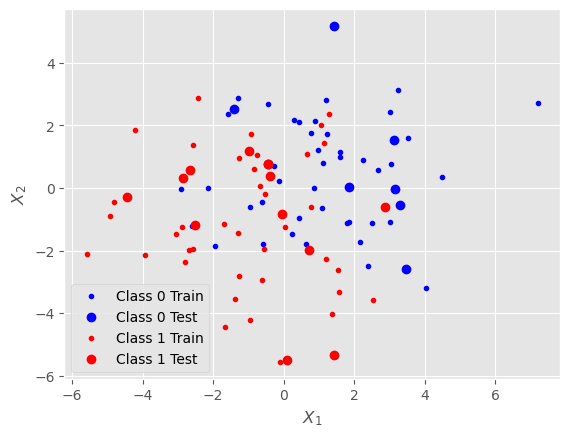

In [7]:
plot_data_and_model_predictions(X_linear_train, y_linear_train,
                                X_linear_test, y_linear_test)

The test data looks similar to the training data because random shuffling allows both sets to represent the overall data distribution.

## Plotting the nonlinear data

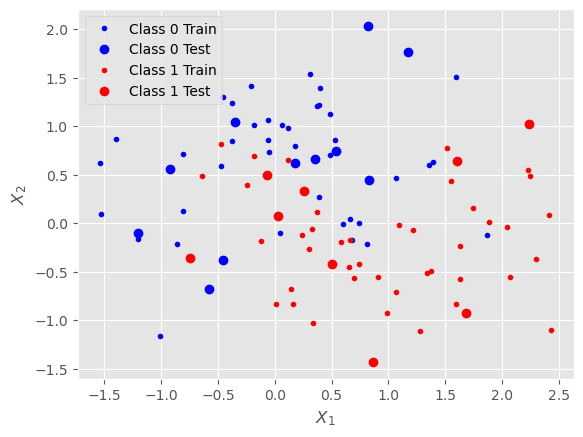

In [10]:
plot_data_and_model_predictions(X_nonlinear_train, y_nonlinear_train,
                                X_nonlinear_test, y_nonlinear_test)

The moon-shaped structure is not clearly visible at this stage due to the high noise level. We will examine it further as we proceed with the assignment.

## KNN Implementation

In [13]:
class KNN:
    """
    K-Nearest Neighbor (KNN) classifier.

    This class implements a simple KNN classifier for supervised
    classification. The model does not perform explicit training,
    but stores the training data and uses it during prediction.

    For each test sample, the classifier:
    1) Computes distances to all training samples.
    2) Selects the k nearest neighbors.
    3) Predicts the class label by majority voting.

    Attributes
    ----------
    X_train : numpy.ndarray, shape (n_train_samples, n_features)
        Feature matrix of the training data.

    y_train : numpy.ndarray, shape (n_train_samples,)
        Numerical class labels of the training data.
        In this assignment, labels are restricted to 0 or 1.

    classes : numpy.ndarray
        Array of unique class labels.

    k : int, optional (default=5)
        Number of nearest neighbors used for voting.
        Controls the model complexity.

    Methods
    -------
    predict(X_test)
        Predicts class labels for the given test samples
        using the KNN algorithm.
    """
    
    def __init__(self, X_train, y_train, k=5):
        self.X_train = X_train
        self.y_train = y_train
        self.classes = np.unique(y_train)
        self.k = k
    
    def predict(self, X_test):
        """
        Predict class labels for the given test samples using KNN.

        This method returns numerical class labels, because the output
        is used for accuracy evaluation and visualization (e.g., contourf),
        which require numeric values. In this assignment, labels are restricted to 0 or 1.

        Parameters
        ----------
        X_test : numpy.ndarray, shape (n_test_samples, n_features)
            Test feature matrix.
            Each row represents one test sample.

        Returns
        -------
        y_pred : numpy.ndarray, shape (n_test_samples,)
            Predicted numerical class labels.
        """
        
        y_pred = []
        
        for x in X_test:
            # Compute Euclidean distances to all training points
            dists = np.linalg.norm(self.X_train - x, axis=1)  # shape: (n_train,)

            # Get indices of the k nearest neighbors
            nn_idx = np.argsort(dists)[:self.k] # argsort performs a full sort (O(N log N)), which contributes to the
                                                # computational cost of KNN, together with the distance computation (O(ND))

            # Majority vote among neighbor labels (numeric labels required)
            nn_labels = self.y_train[nn_idx]

            # 3) Count votes for each class
            counts = np.bincount(nn_labels) # np.bincount counts the frequency of each non-negative integer value in an array
                                            # and returns an array where the index represents the value and the element its count
                                            # np.bincount creates an array whose indices run from 0 to max(label)
                                            # Missing labels are automatically filled with zeros
                                            # labels are 0/1 in this assignment, so np.bincount is safe and efficient.
        
            # Find classes with maximum votes
            max_count = counts.max()
            candidates = np.where(counts == max_count)[0] # np.where(condition) returns a tuple containing index arrays
                                                          # Each element corresponds to one dimension
                                                          # For 1D arrays, the indices are stored in the first element

            # Randomly choose one if there is a tie
            pred_label = np.random.choice(candidates) # This avoids systematic bias toward smaller class labels,
                                                      # unlike argmax which always selects the first maximum

            y_pred.append(pred_label)
        
        return np.array(y_pred)


## Linear Classification and KNN for k=1

Text(0.5, 1.0, 'Accuracy: 0.65')

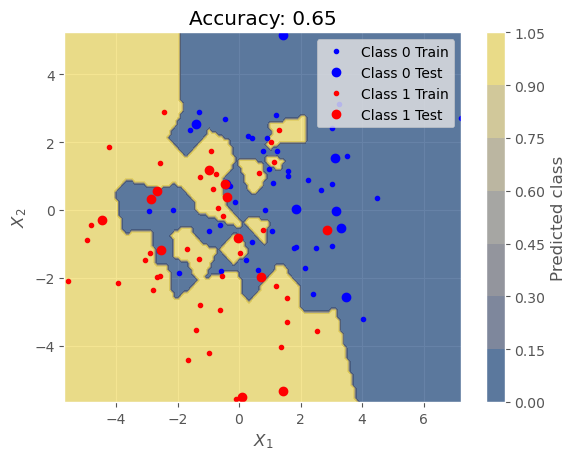

In [15]:
knn = KNN(X_linear_train, y_linear_train, k=1)
plot_data_and_model_predictions(X_linear_train, 
                                y_linear_train, 
                                X_linear_test, 
                                y_linear_test,knn)
y_linear_test_pred = knn.predict(X_linear_test)

accuracy = (y_linear_test==y_linear_test_pred).mean()

# Check that the obtained accuracy is close to the expected value (0.65)
# within a relative tolerance of 5%; otherwise, raise an error

assert np.allclose(accuracy, 0.65, rtol=5e-2)
plt.title(f'Accuracy: {accuracy:0.2}')

## Linear Classification and KNN for k=10

Text(0.5, 1.0, 'Accuracy: 0.8')

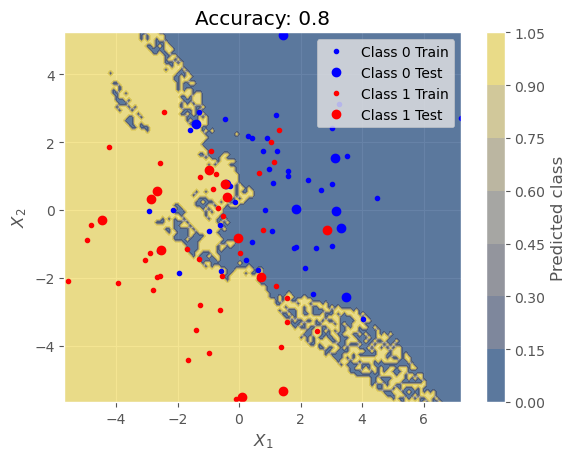

In [17]:
knn = KNN(X_linear_train, y_linear_train, k=10)
plot_data_and_model_predictions(X_linear_train, 
                                y_linear_train, 
                                X_linear_test, 
                                y_linear_test,knn)
y_linear_test_pred = knn.predict(X_linear_test)
accuracy = (y_linear_test==y_linear_test_pred).mean()
assert np.allclose(accuracy, 0.8, rtol=5e-2)
plt.title(f'Accuracy: {accuracy:0.2}')

## Linear Classification and Hyperparameter Optimization

We use grid search to find the best *k* parameter. 

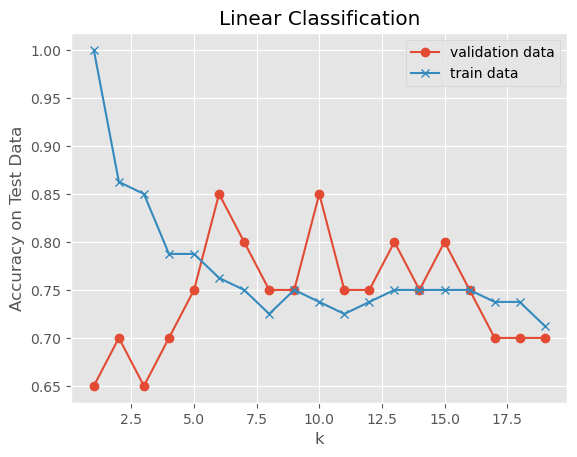

In [19]:
acc_val = [] # Test accuracy
acc_train = [] # Train accuracy
for k in range(1,20):
    knn = KNN(X_linear_train, y_linear_train, k=k)
    acc_val.append((k,(y_linear_test==knn.predict(X_linear_test)).mean()))
    acc_train.append((k,(y_linear_train==knn.predict(X_linear_train)).mean()))

# Separate k values and accuracies from (k, acc) pairs
k, val_acc = zip(*acc_val)
_, train_acc = zip(*acc_train)

plt.plot(k, val_acc,'o-', k, train_acc,'x-')
plt.xlabel('k')
plt.ylabel('Accuracy on Test Data')
plt.title('Linear Classification')
plt.legend(['validation data', 'train data'])
plt.savefig('val-vs-train.pdf')

For small values of k (e.g., k = 1 or 2), the model achieves very high
training accuracy but low validation accuracy, indicating overfitting.

For large values of k, both training and validation accuracies decrease,
which indicates underfitting.

An intermediate value of k typically yields the highest validation accuracy
and is therefore selected as the optimal hyperparameter.

Both k = 6 and k = 10 achieve the highest validation accuracy.
We select k = 6, as it represents a simpler model and is less prone to underfitting.

# Non-linear Classification

Now let's look at a data set that could not be classified correctly with a linear method such as the NCC. 

How does the hyperparameter *k* which controls the complexity of the KNN model influence the generalization ability?

## Non-linear Classification and KNN for k=1

Text(0.5, 1.0, 'Accuracy: 0.75')

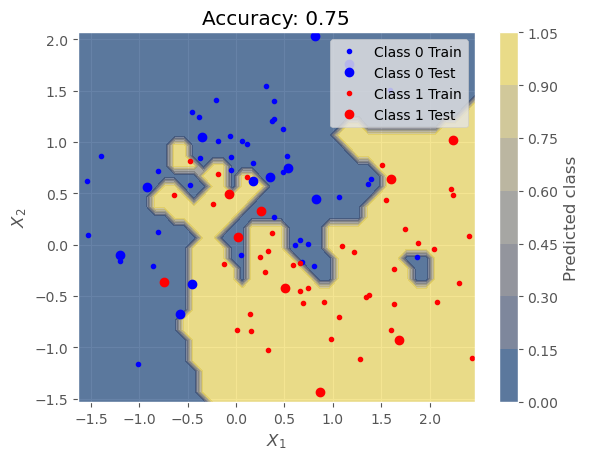

In [23]:
knn = KNN(X_nonlinear_train, y_nonlinear_train, k=1)
plot_data_and_model_predictions(X_nonlinear_train, 
                                y_nonlinear_train, 
                                X_nonlinear_test, 
                                y_nonlinear_test,knn)
y_nonlinear_test_pred = knn.predict(X_nonlinear_test)

accuracy = (y_nonlinear_test==y_nonlinear_test_pred).mean()
assert np.allclose(accuracy, 0.75, rtol=5e-2)
plt.title(f'Accuracy: {accuracy:0.2}')

## Linear Classification and KNN for k=10

Text(0.5, 1.0, 'Accuracy: 0.8')

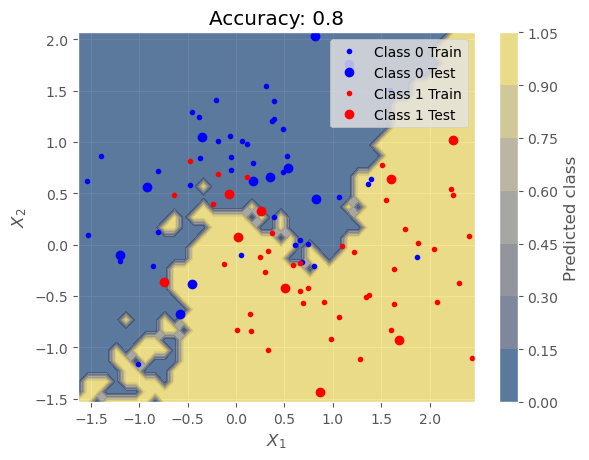

In [25]:
knn = KNN(X_nonlinear_train, y_nonlinear_train, k=10)
plot_data_and_model_predictions(X_nonlinear_train, 
                                y_nonlinear_train, 
                                X_nonlinear_test, 
                                y_nonlinear_test,knn)
y_nonlinear_test_pred = knn.predict(X_nonlinear_test)

accuracy = (y_nonlinear_test==y_nonlinear_test_pred).mean()
assert np.allclose(accuracy, 0.8, rtol=5e-2)
plt.title(f'Accuracy: {accuracy:0.2}')

## Linear Classification and Hyperparameter Optimization

We use grid search to find the best *k* parameter. 

Text(0.5, 1.0, 'Non-linear Classification')

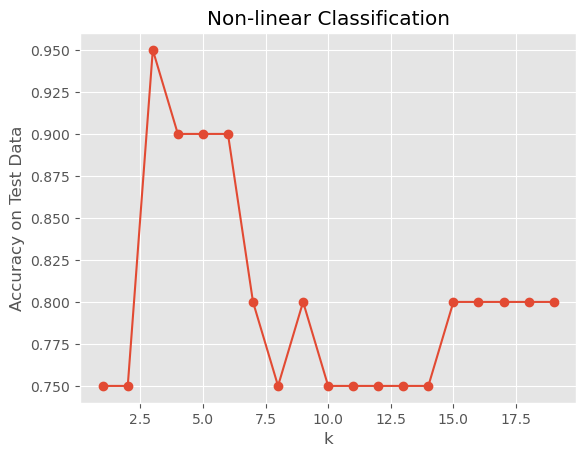

In [27]:
acc_val = []
for k in range(1,20):
    knn = KNN(X_nonlinear_train, y_nonlinear_train, k=k)
    acc_val.append((k,(y_nonlinear_test==knn.predict(X_nonlinear_test)).mean()))

k, acc = zip(*acc_val)
plt.plot(k, acc,'o-')
plt.xlabel('k')
plt.ylabel('Accuracy on Test Data')
plt.title('Non-linear Classification')

For the nonlinear dataset, the highest validation accuracy is achieved at k = 3.
Small values of k capture the local structure of the data, while larger values lead to underfitting.

Due to its complex local structure and noise, the nonlinear dataset exhibits strong sensitivity to the choice of k.

For linearly separable datasets, the decision boundary is simple and stable.
Consequently, varying k has only a limited effect on performance,
leading to relatively smooth changes in accuracy.

## Summary

KNN is a non-parametric and nonlinear classifier.
Therefore, it can adapt well to complex data structures, such as the moon-shaped dataset.

The results show that KNN performs well not only on linearly separable data, but also on nonlinear datasets.
In particular, it achieves higher accuracy on the moon-shaped data by capturing the complex decision boundary.